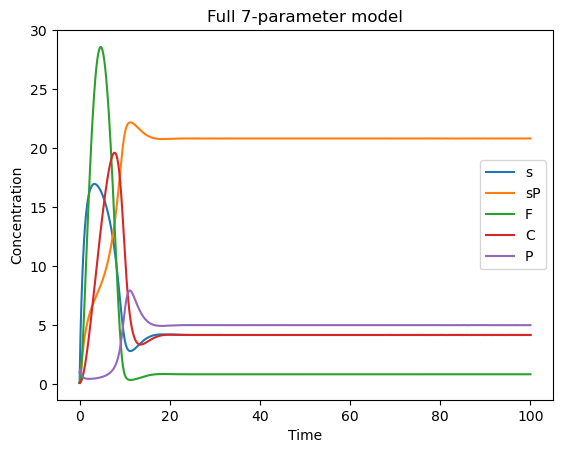

In [1]:
# Full model (7-parameters) for α-synuclein aggregation

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def full_model(t, y, params):
    s, sP, F, C, P = y
    
    m, gamma_s, omega, nu_s, gamma, nu, Lambda, tau = params
    
    ds_dt = m - gamma_s * s * P - omega * s
    dsP_dt = gamma_s * s * P - nu_s * sP
    dF_dt = omega * s - gamma * F * P
    dC_dt = gamma * F * P - nu * C
    dP_dt = Lambda - P / tau - gamma * F * P + nu * C - gamma_s * s * P + nu_s * sP
    
    return [ds_dt, dsP_dt, dF_dt, dC_dt, dP_dt]


# parameters
params = [25, 1.0, 1.0, 1.0, 1.0, 1.0, 5.0, 1.0]

# initial conditions
y0 = [0.1, 0.1, 0.1, 0.1, 1.0]

t_span = (0, 100)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(full_model, t_span, y0, args=(params,), t_eval=t_eval)

# plot
labels = ["s", "sP", "F", "C", "P"]
for i in range(5):
    plt.plot(sol.t, sol.y[i], label=labels[i])

plt.legend()
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Full 7-parameter model")
plt.show()

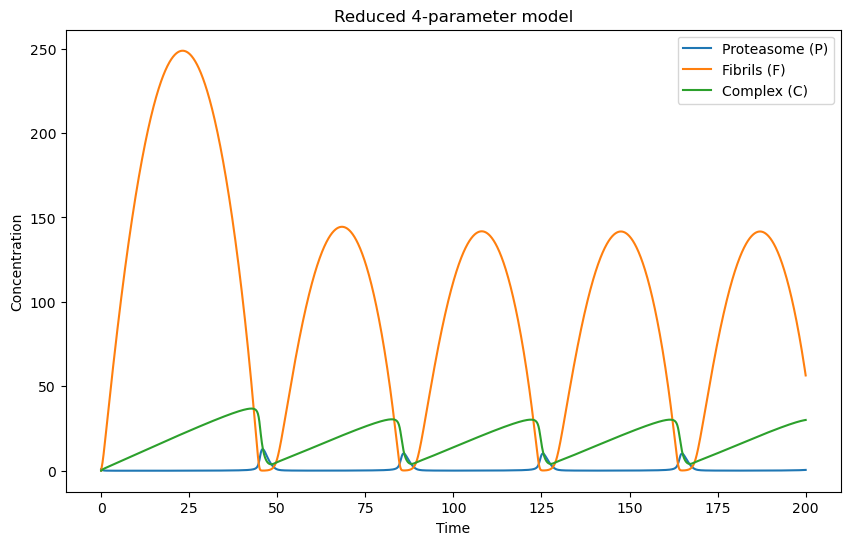

In [3]:
# Reduced (4-parameters) model for α-synuclein aggregation

def reduced_model(t, y, params):
    F, C, P = y
    m, gamma, nu, sigma = params
    
    dF_dt = m / (1 + P) - gamma * F * P
    dC_dt = gamma * F * P - nu * C
    dP_dt = sigma - P - gamma * F * P + nu * C
    
    return [dF_dt, dC_dt, dP_dt]


# parameters (όπως paper fig.2)
params = [25, 1.0, 1.0, 1.0]

# initial conditions
y0 = [0.1, 0.1, 1.0]

t_span = (0, 200)
t_eval = np.linspace(*t_span, 2000)

sol = solve_ivp(reduced_model, t_span, y0, args=(params,), t_eval=t_eval)

F, C, P = sol.y

plt.figure(figsize=(10,6))
plt.plot(sol.t, P, label="Proteasome (P)")
plt.plot(sol.t, F, label="Fibrils (F)")
plt.plot(sol.t, C, label="Complex (C)")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Reduced 4-parameter model")
plt.show()

In [5]:
# Protease induction by Protofibrils (s), Oligomers (aaa) or Fibrils (F)

def model_with_induction(t, y, params):
    F, C, P = y
    m, gamma, nu = params[:3]
    
    sigma0, sigma_s_amp, sigma_o, sigma_F_amp, K = params[3:]
    
    # protofibrils approximation
    s = m / (P + 1e-6)
    
    # oligomers ~ 1/P
    olig = 1 / (P + 1e-6)
    
    sigma = (
        sigma0
        + sigma_s_amp * s / (K + s)
        + sigma_o / (K * P + 1)
        + sigma_F_amp * F / (K + F)
    )
    
    dF_dt = m / (1 + P) - gamma * F * P
    dC_dt = gamma * F * P - nu * C
    dP_dt = sigma - P - gamma * F * P + nu * C
    
    return [dF_dt, dC_dt, dP_dt]

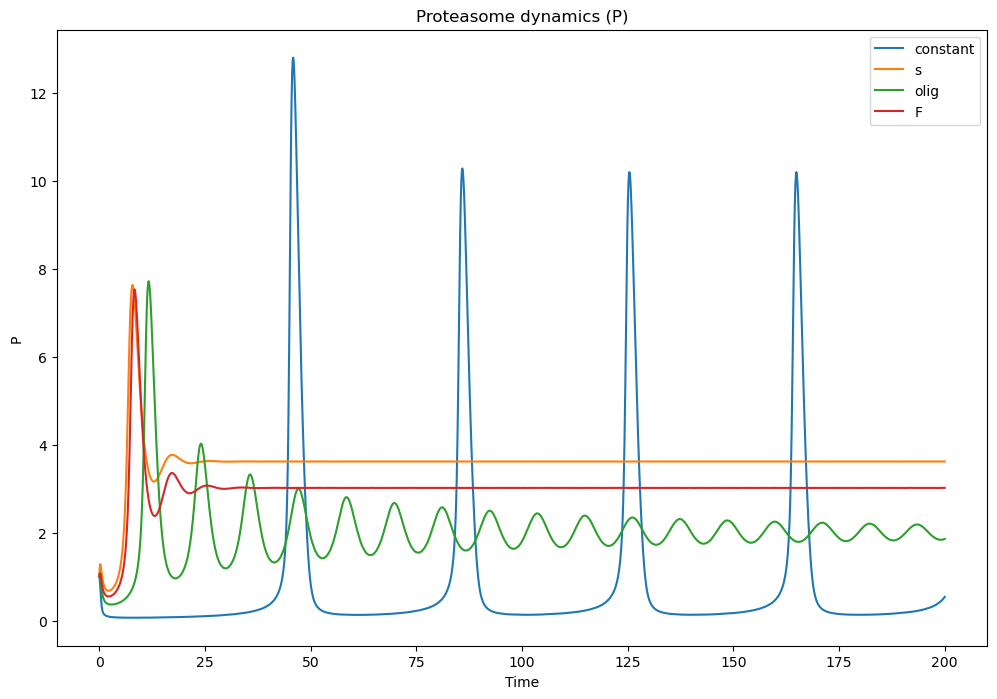

In [7]:
# ---------- MODEL ----------
def model(t, y, params, mode):
    F, C, P = y
    
    m, gamma, nu = params['m'], params['gamma'], params['nu']
    sigma0 = params['sigma0']
    amp = params['amp']
    K = params['K']
    
    eps = 1e-6
    
    # protofibrils approx
    s = m / (P + eps)
    
    # oligomers ~ 1/P
    olig = 1 / (P + eps)
    
    # ---- induction modes ----
    if mode == "constant":
        sigma = sigma0
        
    elif mode == "s":
        sigma = sigma0 + amp * s / (K + s)
        
    elif mode == "olig":
        sigma = sigma0 + amp * olig / (K + olig)
        
    elif mode == "F":
        sigma = sigma0 + amp * F / (K + F)
    
    # ---- ODEs ----
    dF_dt = m / (1 + P) - gamma * F * P
    dC_dt = gamma * F * P - nu * C
    dP_dt = sigma - P - gamma * F * P + nu * C
    
    return [dF_dt, dC_dt, dP_dt]


# ---------- PARAMETERS ----------
params = {
    'm': 25,        # over threshold -> oscillations
    'gamma': 1.0,
    'nu': 1.0,
    'sigma0': 1.0,
    'amp': 3.0,     # strength of induction
    'K': 1.0
}

y0 = [0.1, 0.1, 1.0]
t_span = (0, 200)
t_eval = np.linspace(*t_span, 3000)

modes = ["constant", "s", "olig", "F"]
results = {}

# ---------- RUN ----------
for mode in modes:
    sol = solve_ivp(model, t_span, y0, args=(params, mode), t_eval=t_eval)
    results[mode] = sol

# ---------- PLOT ----------
plt.figure(figsize=(12,8))

for mode in modes:
    P = results[mode].y[2]
    plt.plot(t_eval, P, label=mode)

plt.legend()
plt.title("Proteasome dynamics (P)")
plt.xlabel("Time")
plt.ylabel("P")
plt.show()

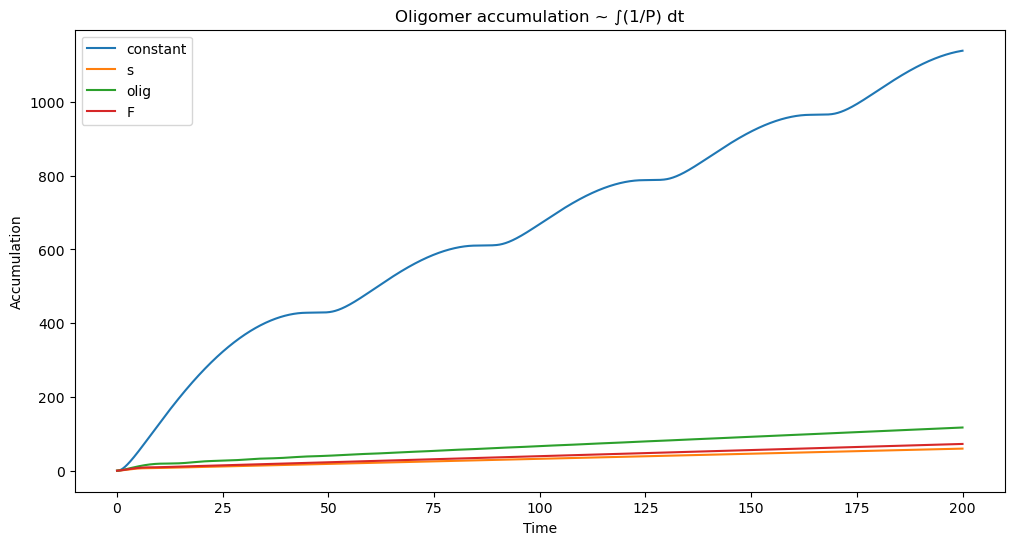

In [9]:
plt.figure(figsize=(12,6))

for mode in modes:
    P = results[mode].y[2]
    olig_proxy = np.cumsum(1 / (P + 1e-6)) * (t_eval[1] - t_eval[0])
    plt.plot(t_eval, olig_proxy, label=mode)

plt.legend()
plt.title("Oligomer accumulation ~ ∫(1/P) dt")
plt.xlabel("Time")
plt.ylabel("Accumulation")
plt.show()

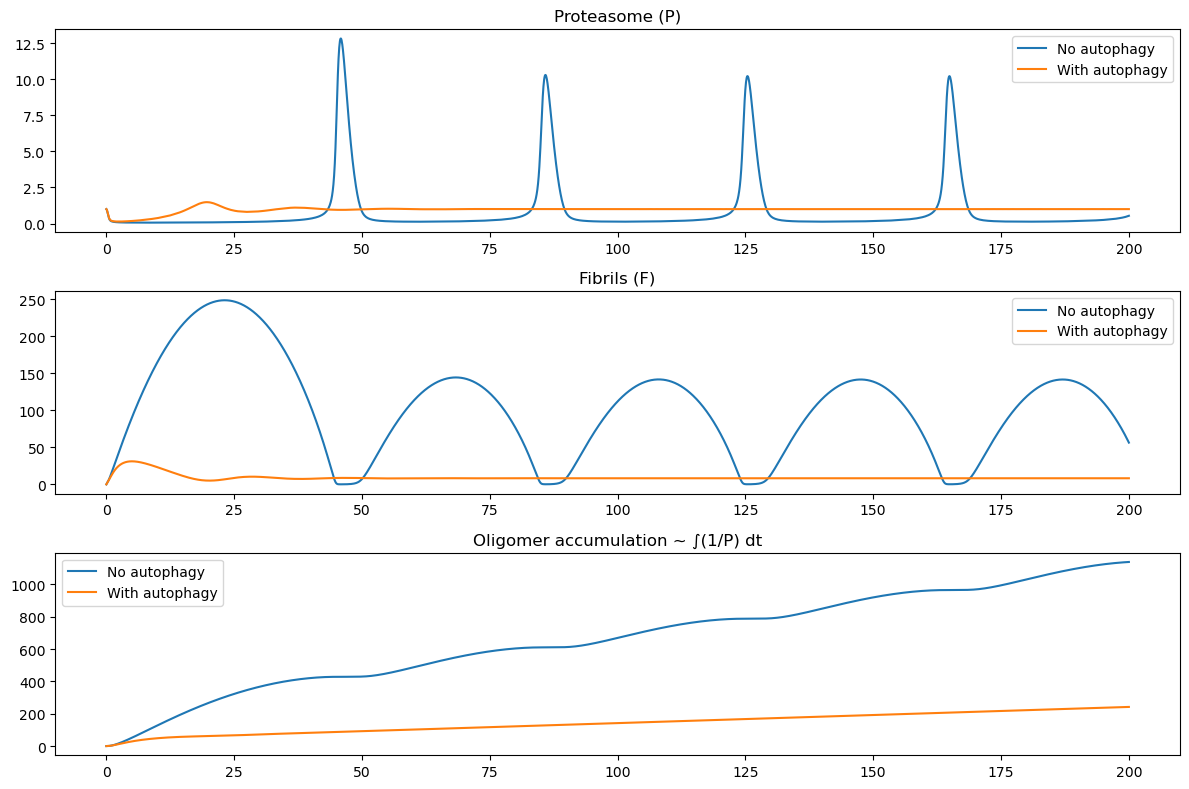

In [11]:
# Model including the effect of autophagy

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ----------- MODELS -----------

def model_no_autophagy(t, y, params):
    F, C, P = y
    m, gamma, nu, sigma = params
    
    dF_dt = m / (1 + P) - gamma * F * P
    dC_dt = gamma * F * P - nu * C
    dP_dt = sigma - P - gamma * F * P + nu * C
    
    return [dF_dt, dC_dt, dP_dt]


def model_with_autophagy(t, y, params):
    F, C, P = y
    m, gamma, nu, sigma, delta = params
    
    dF_dt = m / (1 + P) - gamma * F * P - delta * F
    dC_dt = gamma * F * P - nu * C
    dP_dt = sigma - P - gamma * F * P + nu * C
    
    return [dF_dt, dC_dt, dP_dt]


# ----------- PARAMETERS -----------

params_no_auto = [25, 1.0, 1.0, 1.0]
params_auto = [25, 1.0, 1.0, 1.0, 0.5]  # delta = 0.5

y0 = [0.1, 0.1, 1.0]
t_span = (0, 200)
t_eval = np.linspace(*t_span, 3000)

# ----------- SIMULATIONS -----------

sol_no = solve_ivp(model_no_autophagy, t_span, y0, args=(params_no_auto,), t_eval=t_eval)
sol_auto = solve_ivp(model_with_autophagy, t_span, y0, args=(params_auto,), t_eval=t_eval)

F_no, C_no, P_no = sol_no.y
F_auto, C_auto, P_auto = sol_auto.y

# ----------- PLOTS -----------

plt.figure(figsize=(12,8))

# Proteasome
plt.subplot(3,1,1)
plt.plot(t_eval, P_no, label="No autophagy")
plt.plot(t_eval, P_auto, label="With autophagy")
plt.title("Proteasome (P)")
plt.legend()

# Fibrils
plt.subplot(3,1,2)
plt.plot(t_eval, F_no, label="No autophagy")
plt.plot(t_eval, F_auto, label="With autophagy")
plt.title("Fibrils (F)")
plt.legend()

# Oligomer proxy
olig_no = np.cumsum(1/(P_no+1e-6))*(t_eval[1]-t_eval[0])
olig_auto = np.cumsum(1/(P_auto+1e-6))*(t_eval[1]-t_eval[0])

plt.subplot(3,1,3)
plt.plot(t_eval, olig_no, label="No autophagy")
plt.plot(t_eval, olig_auto, label="With autophagy")
plt.title("Oligomer accumulation ~ ∫(1/P) dt")
plt.legend()

plt.tight_layout()
plt.show()